In [6]:
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [7]:
x = 6 * np.random.rand(200, 1) -3 
y = 0.8 * x ** 2 + 0.9 * x + 2 + np.random.randn(200,1)



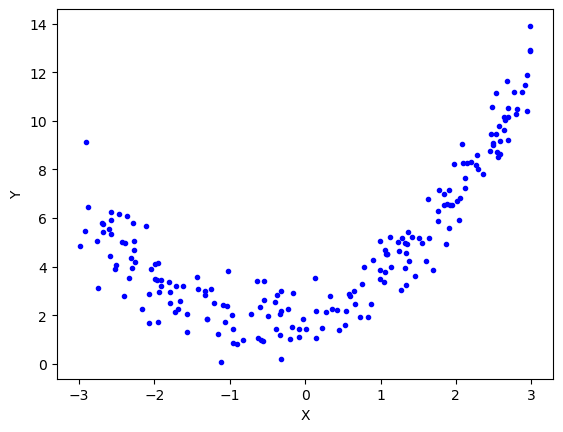

In [9]:
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [10]:
# train test split 
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [11]:
# applying linear regression 
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred=y_pred)

0.261661541942097

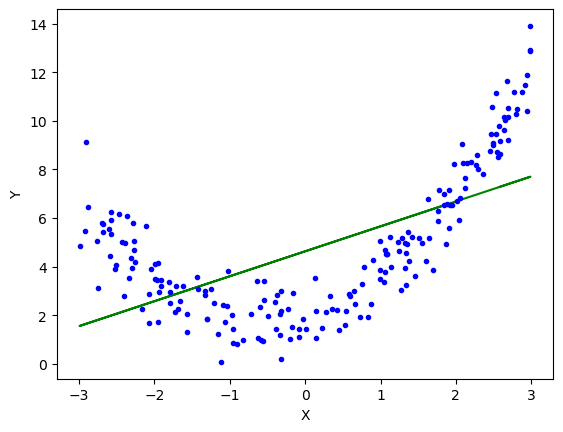

In [14]:
plt.plot(X_train, lr.predict(X_train), color='green')
plt.plot(x,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
# applying polynomial linear regression 
poly = PolynomialFeatures(degree=2, include_bias=True)

x_train_trans = poly.fit_transform(X_train)
x_test_trans = poly.transform(X_test)

In [16]:
print(X_train[0])
print(x_train_trans[0])

[2.5832846]
[1.         2.5832846  6.67335934]


In [17]:
# include_bios parameter is set to false to remove the bias term (the first column of 1s) from the transformed features. This is because the LinearRegression model will automatically include an intercept term, so we don't need to include it in the polynomial features. By setting include_bias=False, we ensure that the transformed features only include the polynomial terms without the bias term, which allows the LinearRegression model to fit the data correctly without redundancy.

In [18]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = lr.predict(x_test_trans)

In [22]:
r2_score(y_test,y_pred=y_pred)

0.8881281317210458

In [23]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88698388 0.82387178]]
[1.95274985]
